In [28]:
import numpy as np
import matplotlib.pyplot as plt
from repeaters_NV import RepeaterParams
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

sns.set_theme(style="white", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.bottom": True,
    "ytick.left": True,
    "figure.autolayout": True
})

def entanglement_rate_vs_distance(params, distances):
    """
    Elementary entanglement generation rate [pairs/s]
    as a function of elementary link distance.
    """

    distances = np.asarray(distances)

    # Each photon travels half the elementary link
    half_dist = distances / 2

    P_click = (
        params.p_det
        * params.eta_c
        * params.eta_M
        * 10 ** (-params.alpha * half_dist / 10)
    )

    P_click = 1-(1-P_click)**params.M

    # Probability both photons arrive and a Bell-state measurement succeeds
    P_both = 0.5 * P_click**2

    # Expected rate
    rate = params.nu * P_both

    return rate

In [31]:
params = RepeaterParams()
params.p_det     = 0.95
params.alpha     = 0.18
params.V         = 0.95
params.nu        = 167e3
params.R_dark    = 100
params.delta_det = 100e-12
params.eta_c     = 0.8
params.P_BSM     = 0.9993
params.eta_M     = 0.46
params.T_coh     = 0.05
params.M = 1


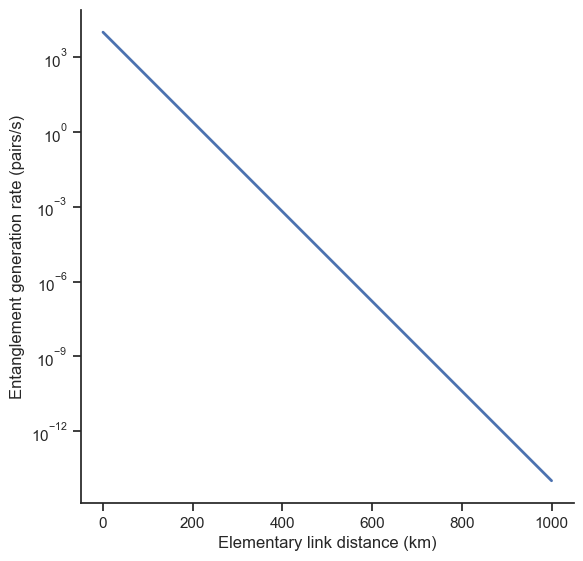

In [32]:
distances = np.linspace(0, 1000, 500)

rates = entanglement_rate_vs_distance(params, distances)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(distances, rates, lw=2)
ax.set_yscale('log')
ax.set_xlabel("Elementary link distance (km)")
ax.set_ylabel("Entanglement generation rate (pairs/s)")
ax.set_box_aspect(1) # Forces the plot area to be perfectly square
# Enable minor tick labels and set formatter
plt.tick_params(axis='y', which='minor')

plt.savefig('tests/prunning.png', bbox_inches='tight')
plt.show()

Saved percolation_no_mux.png and percolation_mux20.png


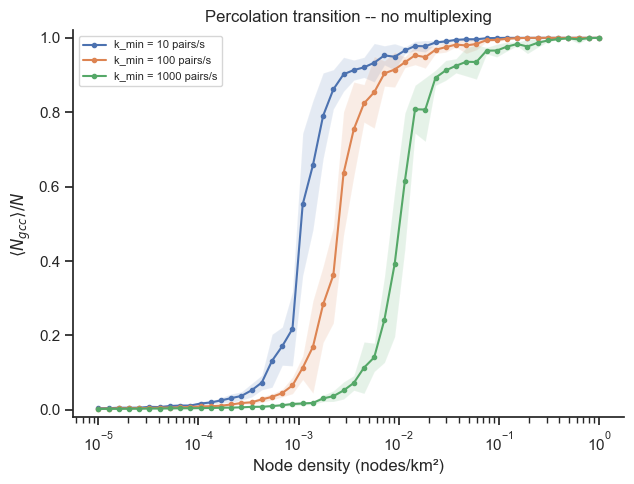

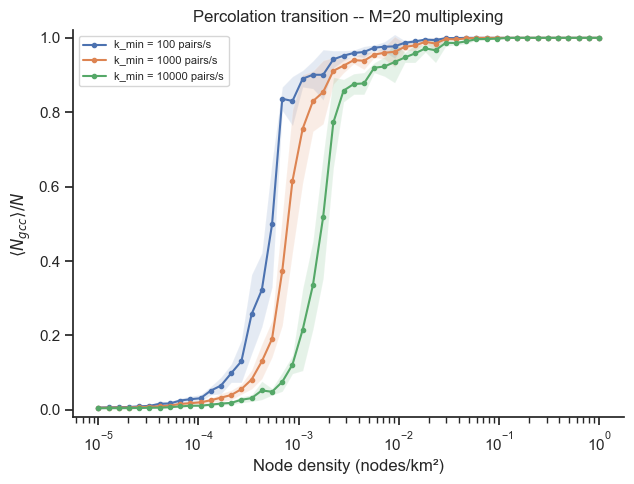

In [36]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "percolation_results.csv"

df = pd.read_csv(INPUT_CSV)

# mean +/- std over repetitions, per (mux_type, k_min, density)
summary = (
    df.groupby(["mux_type", "k_min", "density"])["giant_fraction"]
      .agg(["mean", "std", "count"])
      .reset_index()
)


def plot_case(ax, mux_label, title):
    sub = summary[summary["mux_type"] == mux_label]
    for k_min, grp in sub.groupby("k_min"):
        grp = grp.sort_values("density")
        ax.plot(grp["density"], grp["mean"], marker="o", markersize=3,
                label=f"k_min = {k_min:g} pairs/s")
        ax.fill_between(
            grp["density"],
            grp["mean"] - grp["std"],
            grp["mean"] + grp["std"],
            alpha=0.15,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Node density (nodes/km²)")
    ax.set_ylabel(r"$\langle N_{gcc} \rangle / N$")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.legend(fontsize=8)


fig1, ax1 = plt.subplots(figsize=(6.5, 5))
plot_case(ax1, "no_mux", "Percolation transition -- no multiplexing")
fig1.tight_layout()
fig1.savefig("percolation_no_mux.png", dpi=150)

fig2, ax2 = plt.subplots(figsize=(6.5, 5))
plot_case(ax2, "mux20", "Percolation transition -- M=20 multiplexing")
fig2.tight_layout()
fig2.savefig("percolation_mux20.png", dpi=150)

print("Saved percolation_no_mux.png and percolation_mux20.png")

In [37]:

INPUT_CSV = "density_results.csv"

df = pd.read_csv(INPUT_CSV)

# mean +/- std over repetitions, per (mux_type, density)
summary = (
    df.groupby(["mux_type", "density"])[["avg_skr", "avg_qber", "avg_fidelity", "reachability"]]
      .agg(["mean", "std"])
      .reset_index()
)

LABELS = {"no_mux": "No multiplexing", "mux20": "M = 20 multiplexing"}
COLORS = {"no_mux": "tab:blue", "mux20": "tab:orange"}


def plot_metric(metric, ylabel, title, filename, yscale="linear", ylim=None):
    fig, ax = plt.subplots(figsize=(6.5, 5))

    for mux_type in ["no_mux", "mux20"]:
        sub = summary[summary["mux_type"] == mux_type].sort_values("density")
        if sub.empty:
            continue
        x = sub["density"]
        mean = sub[(metric, "mean")]
        std = sub[(metric, "std")].fillna(0.0)

        ax.plot(x, mean, marker="o", markersize=3,
                label=LABELS[mux_type], color=COLORS[mux_type])
        ax.fill_between(x, mean - std, mean + std,
                         alpha=0.15, color=COLORS[mux_type])

    ax.set_xscale("log")
    ax.set_yscale(yscale)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel(r"Node density (nodes/km$^2$)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)
    print(f"Saved {filename}")


# SKR: can be 0 or span many orders of magnitude -> symlog handles the zeros
plot_metric("avg_skr", "Avg. SKR (bit/s)",
            "Secret key rate vs. density", "skr_vs_density_test.png",
            yscale="symlog")

plot_metric("avg_qber", "Avg. QBER",
            "QBER vs. density", "qber_vs_density_test.png",
            yscale="linear", ylim=(0, 0.55))

plot_metric("avg_fidelity", "Avg. Fidelity",
            "Fidelity vs. density", "fidelity_vs_density_test.png",
            yscale="linear", ylim=(0.2, 1.02))

plot_metric("reachability", "Reachability",
            "Reachability vs. density", "reachability_vs_density_test.png",
            yscale="linear", ylim=(-0.02, 1.02))

print("Done.")

Saved skr_vs_density_test.png
Saved qber_vs_density_test.png
Saved fidelity_vs_density_test.png
Saved reachability_vs_density_test.png
Done.
